## **Bernstein-Vazirani Algorithm**

In [54]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeAlgiers
from qiskit.visualization import plot_histogram
import numpy as np
from q_utils.style import dark_theme

In [55]:
def bv_oracle(n):
    if n<=0:
        print("Invalid input. The qubit count must be greater than 0")
        return 
        
    oracle = QuantumCircuit(n+1)
    
    b = np.random.randint(1,2**n)
    b_string = format(b,'0'+str(n)+'b')
    b_str = b_string[::-1]
    
    for qubit in range(len(b_str)):
        if b_str[qubit] == '1':
            oracle.cx(qubit,n)
        
    return oracle, b_string

In [56]:
def bv_algorithm(oracle,n):
    qc = QuantumCircuit(n+1,n)
    
    qc.x(n)
    qc.h(n)
    
    [qc.h(i) for i in range(n)]
    
    qc.barrier()
    qc = qc.compose(oracle)
    qc.barrier()
    
    [qc.h(i) for i in range(n)]
    
    [qc.measure(i,i) for i in range(n)]
    
    return qc

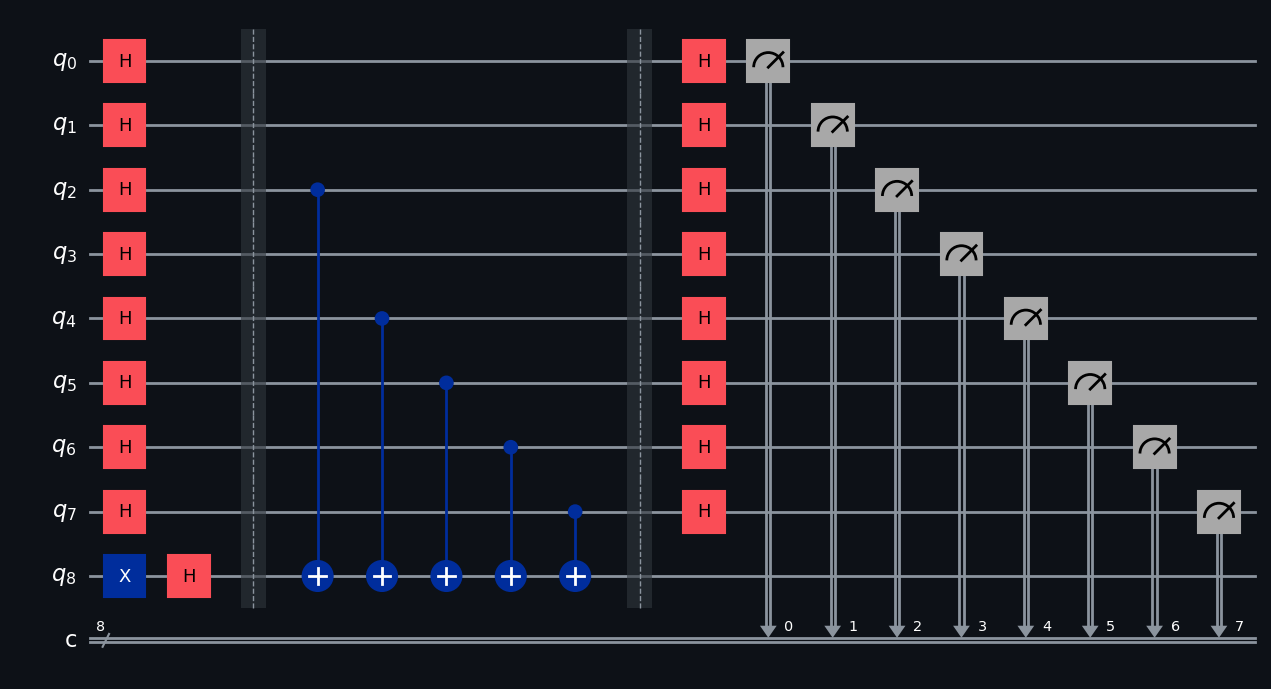

In [57]:
n = int(input("Enter number of qubits: "))

oracle_instance, secret_b = bv_oracle(n)
bv_circuit = bv_algorithm(oracle_instance,n)
bv_circuit.draw('mpl',style = dark_theme)

counts: {'11110100': 1024}
Secret  bit: 11110100


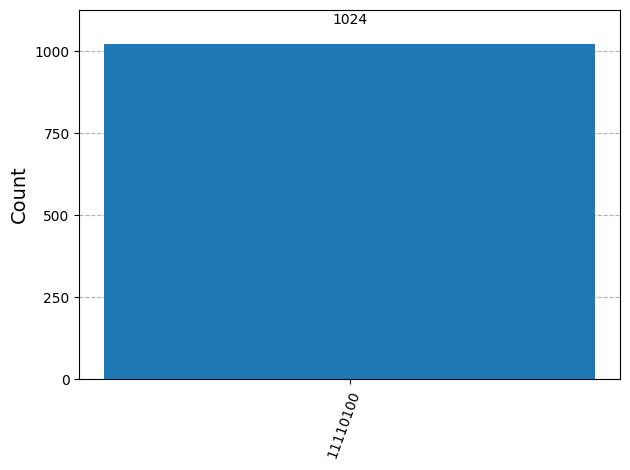

In [58]:
sim = AerSimulator()
transpiled_ct = transpile(bv_circuit, sim)
counts = sim.run(transpiled_ct, shots=1024).result().get_counts()

print(f"counts: {counts}")
print(f"Secret  bit: {secret_b}")
plot_histogram(counts)

counts  : {'11110100': 941, '11110000': 7, '11111100': 9, '11010100': 10, '11110110': 7, '11110101': 12, '11100100': 10, '00010100': 4, '01110100': 8, '00110100': 2, '10110100': 11, '00011100': 1, '01100100': 1, '01110000': 1}
Secret  bit: 11110100


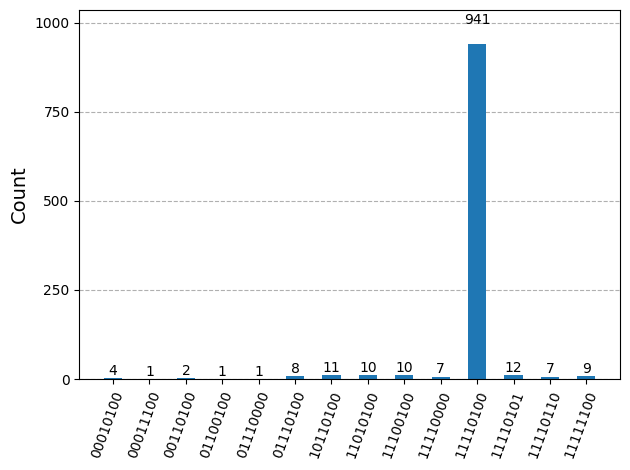

In [59]:
backend = FakeAlgiers()
noise_model = NoiseModel.from_backend(backend=backend)
sim_noise = AerSimulator(noise_model = noise_model)
transpiled_ct_noise = transpile(bv_circuit,sim_noise)
counts_noise = sim_noise.run(transpiled_ct_noise, shots=1024).result().get_counts()

print(f"counts  : {counts_noise}")
print(f"Secret  bit: {secret_b}")
plot_histogram(counts_noise)